In [ ]:
import pandas as pd

# 1. Load the datasets
df_area = pd.read_csv('final_imputed_crown_area.csv')
df_height = pd.read_csv('trees_full_with_imputed_crown_height.csv')

# 2. Define the exact columns you want to bring over from df_height
# (Make sure to include OBJECTID so we can match the rows!)
columns_to_keep = [
    'OBJECTID', 
    'tree_group', 
    'CROWN_HEIGHT_interpolated', 
    'height_imputed_flag', 
    'height_model_source'
]

# 3. Merge the datasets
# A 'left' merge keeps everything in df_area and only brings in matching data from df_height
df_combined = df_area.merge(df_height[columns_to_keep], on='OBJECTID', how='left')

# 4. Quick verification
print("--- Merge Complete ---")
print(f"Original Area rows: {len(df_area)}")
print(f"Combined rows:      {len(df_combined)}")

# Check if any merged rows resulted in missing height data
missing_heights = df_combined['CROWN_HEIGHT_interpolated'].isna().sum()
if missing_heights > 0:
    print(f"Note: There are {missing_heights} trees in the Area dataset that didn't have matching Height data.")
else:
    print("All trees successfully matched with height data!")

print(df_combined)

--- Merge Complete ---
Original Area rows: 55082
Combined rows:      55082
Note: There are 583 trees in the Area dataset that didn't have matching Height data.
       Unnamed: 0.1  Unnamed: 0  OBJECTID  \
0                 0           0  26609351   
1                 1           1  26609352   
2                 2           2  26609353   
3                 3           3  26609354   
4                 4           4  26609355   
...             ...         ...       ...   
55077         55077       55077  26665022   
55078         55078       55078  26665023   
55079         55079       55079  26665024   
55080         55080       55080  26665025   
55081         55081       55081  26665026   

                                     SITE_NAME          X          Y  \
0      Dovercourt Road To Muller Road Footpath  359956.40  176260.01   
1      Dovercourt Road To Muller Road Footpath  359933.76  176296.56   
2          Eastville Roundabout M32 Junction 2  361186.30  175261.56   
3          

C:\Users\andre\AppData\Local\Temp\ipykernel_43928\1476861959.py:5: DtypeWarning: Columns (3,5,7,9,11,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_height = pd.read_csv('trees_full_with_imputed_crown_height.csv')


In [16]:
import pandas as pd

# --- 1. Define all our target IDs ---
deciduous_ids = [26634543, 26651091, 26651120, 26664627]
judas_ids = [26660810, 26660811, 26660812, 26660813, 26660814]
cherry_ids = [26664659]

# --- 2. Calculate the Universal Deciduous Averages ---
deciduous_mask = df_combined['tree_group'].str.contains('Deciduous', case=False, na=False)
deciduous_avg_height = df_combined.loc[deciduous_mask, 'CROWN_HEIGHT_interpolated'].mean()
deciduous_avg_area = df_combined.loc[deciduous_mask, 'CROWN_AREA_COMPLETE'].mean()

# SAFETY CHECK: Did it actually find deciduous trees?
if pd.isna(deciduous_avg_height):
    print("🚨 WARNING: Deciduous average is NaN. The word 'Deciduous' might not be in 'tree_group'.")
else:
    print(f"✅ Deciduous Averages Found -> Height: {deciduous_avg_height:.2f}, Area: {deciduous_avg_area:.2f}")

# --- 3. Apply Universal Deciduous Averages ---
dec_target = df_combined['OBJECTID'].isin(deciduous_ids)
df_combined.loc[dec_target, 'CROWN_HEIGHT_interpolated'] = deciduous_avg_height
df_combined.loc[dec_target, 'CROWN_AREA_COMPLETE'] = deciduous_avg_area
df_combined.loc[dec_target, 'height_imputed_flag'] = 1
df_combined.loc[dec_target, 'height_model_source'] = 'universal_deciduous_mean'

# --- 4. Apply Judas Tree Averages (Using Common Name) ---
judas_avg_height = df_combined.groupby('COMMON_NAME')['CROWN_HEIGHT_interpolated'].mean().get('Judas Tree')
judas_avg_area = df_combined.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].mean().get('Judas Tree')

judas_target = df_combined['OBJECTID'].isin(judas_ids)
df_combined.loc[judas_target, 'CROWN_HEIGHT_interpolated'] = judas_avg_height
df_combined.loc[judas_target, 'CROWN_AREA_COMPLETE'] = judas_avg_area
df_combined.loc[judas_target, 'COMMON_NAME'] = 'Judas Tree' # Standardize the name!
df_combined.loc[judas_target, 'height_imputed_flag'] = 1
df_combined.loc[judas_target, 'height_model_source'] = 'species_mean'

# --- 5. Apply Cherry Tree Averages (Using Common Name) ---
cherry_avg_height = df_combined.groupby('COMMON_NAME')['CROWN_HEIGHT_interpolated'].mean().get('Cherry')
cherry_avg_area = df_combined.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].mean().get('Cherry')

cherry_target = df_combined['OBJECTID'].isin(cherry_ids)
df_combined.loc[cherry_target, 'CROWN_HEIGHT_interpolated'] = cherry_avg_height
df_combined.loc[cherry_target, 'CROWN_AREA_COMPLETE'] = cherry_avg_area
df_combined.loc[cherry_target, 'COMMON_NAME'] = 'Cherry' # Standardize the name!
df_combined.loc[cherry_target, 'height_imputed_flag'] = 1
df_combined.loc[cherry_target, 'height_model_source'] = 'species_mean'

# --- 6. Final Verification Printout ---
columns_to_view = [
    'OBJECTID', 'COMMON_NAME', 'tree_group', 
    'CROWN_HEIGHT_interpolated', 'CROWN_AREA_COMPLETE', 
    'height_model_source'
]
all_target_ids = deciduous_ids + judas_ids + cherry_ids
final_check_df = df_combined[df_combined['OBJECTID'].isin(all_target_ids)]

print(f"\n--- Final Verification: Showing all {len(final_check_df)} updated trees ---")
display(final_check_df[columns_to_view].sort_values(by='OBJECTID'))

✅ Deciduous Averages Found -> Height: 8.13, Area: 82.18

--- Final Verification: Showing all 10 updated trees ---


,OBJECTID,COMMON_NAME,tree_group,CROWN_HEIGHT_interpolated,CROWN_AREA_COMPLETE,height_model_source
24891,26634543,NaN,other,8.131150,82.177405,universal_deciduous_mean
41300,26651091,NaN,other,8.131150,82.177405,universal_deciduous_mean
41329,26651120,NaN,other,8.131150,82.177405,universal_deciduous_mean
50904,26660810,Judas Tree,other,1.610952,4.000206,species_mean
50905,26660811,Judas Tree,other,1.610952,4.000206,species_mean
50906,26660812,Judas Tree,other,1.610952,4.000206,species_mean
50907,26660813,Judas Tree,other,1.610952,4.000206,species_mean
50908,26660814,Judas Tree,other,1.610952,4.000206,species_mean
54683,26664627,NaN,other,8.131150,82.177405,universal_deciduous_mean
54715,26664659,Cherry,other,5.404839,42.839905,species_mean


In [17]:
print(df_combined)

       Unnamed: 0.1  Unnamed: 0  OBJECTID  \
0                 0           0  26609351   
1                 1           1  26609352   
2                 2           2  26609353   
3                 3           3  26609354   
4                 4           4  26609355   
...             ...         ...       ...   
55077         55077       55077  26665022   
55078         55078       55078  26665023   
55079         55079       55079  26665024   
55080         55080       55080  26665025   
55081         55081       55081  26665026   

                                     SITE_NAME          X          Y  \
0      Dovercourt Road To Muller Road Footpath  359956.40  176260.01   
1      Dovercourt Road To Muller Road Footpath  359933.76  176296.56   
2          Eastville Roundabout M32 Junction 2  361186.30  175261.56   
3          Eastville Roundabout M32 Junction 2  361181.52  175236.67   
4          Eastville Roundabout M32 Junction 2  361164.98  175223.73   
...                        

In [18]:
# now radius subset apply

# 1. Load your radius dataset if it's not already in memory
trees_within_radius = pd.read_csv('trees_within_radius.csv')

# 2. Filter the combined dataset
# This keeps ONLY the rows where the OBJECTID exists in the radius dataset
df_final_subset = df_combined[df_combined['OBJECTID'].isin(trees_within_radius['OBJECTID'])]

# 3. Verification Check
print("--- Radius Filtering Complete ---")
print(f"Original dataset rows: {len(df_combined)}")
print(f"Radius target rows:    {len(trees_within_radius)}")
print(f"Final subset rows:     {len(df_final_subset)}")

# A quick safety check: Did we lose any trees?
if len(df_final_subset) != len(trees_within_radius):
    missing = len(trees_within_radius) - len(df_final_subset)
    print(f"⚠️ Warning: {missing} trees from the radius dataset were not found in the combined dataset.")
else:
    print("✅ Success: Final subset perfectly matches the radius dataset count!")

# 4. Save your final, fully imputed, perfectly filtered dataset
#df_final_subset.to_csv('final_trees_within_radius_imputed.csv', index=False)


--- Radius Filtering Complete ---
Original dataset rows: 55082
Radius target rows:    1397
Final subset rows:     1397
✅ Success: Final subset perfectly matches the radius dataset count!


In [19]:
# now check no NaN's in our height and area 
# Creates a temporary dataframe of just the rows missing their height
nan_rows = df_final_subset[df_final_subset['CROWN_AREA_COMPLETE'].isna()]

print("Rows missing height data:")
print(nan_rows)

Rows missing height data:
Empty DataFrame
Columns: [Unnamed: 0.1, Unnamed: 0, OBJECTID, SITE_NAME, X, Y, EXTENT_EASTING_1, EXTENT_NORTHING_1, EXTENT_EASTING_2, EXTENT_NORTHING_2, LATIN_NAME, COMMON_NAME, FULL_COMMON_NAME, TREE_SPECIES, CROWN_WIDTH, CROWN_HEIGHT, DBH, PLANTING_SEASON, CROWN_AREA_MIDPOINT, CROWN_AREA_COMPLETE, Data Source, tree_group, CROWN_HEIGHT_interpolated, height_imputed_flag, height_model_source]
Index: []

[0 rows x 25 columns]


In [20]:
df_final_subset

,Unnamed: 0.1,Unnamed: 0,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,...,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag,height_model_source
130,130,130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,...,NaN,0.060000,Planting Season 19/20,NaN,3.593897,Original,deciduous,3.580900,1.0,species_log
131,131,131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,...,8.0,0.320000,Not Applicable,10.00,10.000000,Original,deciduous,8.000000,0.0,observed
391,391,391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,...,14.0,0.500000,Not Applicable,150.05,150.050000,Original,deciduous,14.000000,0.0,observed
392,392,392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,...,12.0,0.400000,Not Applicable,60.05,60.050000,Original,deciduous,12.000000,0.0,observed
393,393,393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,...,12.0,0.400000,Not Applicable,60.05,60.050000,Original,deciduous,12.000000,0.0,observed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,54715,54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,...,NaN,0.305455,Not Applicable,NaN,42.839905,Imputed,other,5.404839,1.0,species_mean
54971,54971,54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,...,10.0,0.400000,Not Applicable,150.05,150.050000,Original,deciduous,10.000000,0.0,observed
54972,54972,54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,...,11.0,0.520000,Not Applicable,150.05,150.050000,Original,deciduous,11.000000,0.0,observed
54973,54973,54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,...,12.0,0.440000,Not Applicable,150.05,150.050000,Original,deciduous,12.000000,0.0,observed


In [27]:
columns_to_keep = [
    'OBJECTID',
    'SITE_NAME', 
    'X',
    'Y',
    'EXTENT_EASTING_1',
    'EXTENT_NORTHING_1',	
    'EXTENT_EASTING_2',
    'EXTENT_NORTHING_2',
    'LATIN_NAME',
    'COMMON_NAME',
    'FULL_COMMON_NAME', 
    'TREE_SPECIES',
    'DBH', 
    'CROWN_AREA_COMPLETE',
    'Data Source',
    'tree_group', 
    'CROWN_HEIGHT_interpolated',
    'height_imputed_flag'
]

# 3. Overwrite the dataframe with only that specific subset of columns
df_cleaned = df_final_subset[columns_to_keep]

df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated,height_imputed_flag
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900,1.0
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000,0.0
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000,0.0
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,other,5.404839,1.0
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000,0.0
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000,0.0
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000,0.0


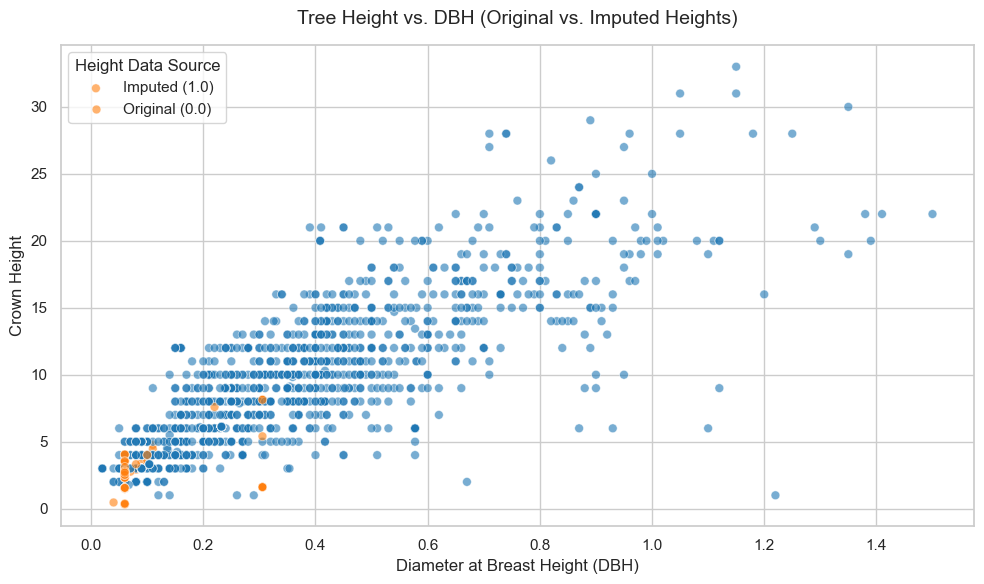

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Fill any NaNs in the flag column with 0.0 (assuming non-imputed trees are 0 or NaN)
# and convert to a string so Seaborn treats it as two distinct categories (colors) 
# instead of a continuous gradient map.
df_plot = df_cleaned.copy()
df_plot['height_imputed_flag'] = df_plot['height_imputed_flag'].fillna(0.0).astype(str)

# 2. Set up the visual style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the scatter plot
# Using alpha=0.6 makes the dots slightly transparent so we can see overlapping points
sns.scatterplot(
    data=df_plot,
    x='DBH',
    y='CROWN_HEIGHT_interpolated',
    hue='height_imputed_flag',
    palette={'0.0': '#1f77b4', '1.0': '#ff7f0e'}, # Blue for real, Orange for imputed
    alpha=0.6,
    s=40 # Dot size
)

# 4. Add clear labels and a title
plt.title('Tree Height vs. DBH (Original vs. Imputed Heights)', fontsize=14, pad=15)
plt.xlabel('Diameter at Breast Height (DBH)', fontsize=12)
plt.ylabel('Crown Height', fontsize=12)

# 5. Clean up the legend
plt.legend(title='Height Data Source', labels=['Imputed (1.0)', 'Original (0.0)'])

# 6. Show the plot
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
import numpy as np

# 1. Make a safe copy of the dataframe
df_cleaned = df_cleaned.copy()

# 2. Fix Eastings: Find where they are 'inf' and replace with X
# np.isinf() safely finds both positive and negative infinity
mask_easting_1 = np.isinf(df_cleaned['EXTENT_EASTING_1'])
df_cleaned.loc[mask_easting_1, 'EXTENT_EASTING_1'] = df_cleaned.loc[mask_easting_1, 'X']

# Assuming you also have an EXTENT_EASTING_2 column with the same issue
if 'EXTENT_EASTING_2' in df_cleaned.columns:
    mask_easting_2 = np.isinf(df_cleaned['EXTENT_EASTING_2'])
    df_cleaned.loc[mask_easting_2, 'EXTENT_EASTING_2'] = df_cleaned.loc[mask_easting_2, 'X']

# 3. Fix Northings: Find where they are 'inf' and replace with Y
mask_northing_1 = np.isinf(df_cleaned['EXTENT_NORTHING_1'])
df_cleaned.loc[mask_northing_1, 'EXTENT_NORTHING_1'] = df_cleaned.loc[mask_northing_1, 'Y']

if 'EXTENT_NORTHING_2' in df_cleaned.columns:
    mask_northing_2 = np.isinf(df_cleaned['EXTENT_NORTHING_2'])
    df_cleaned.loc[mask_northing_2, 'EXTENT_NORTHING_2'] = df_cleaned.loc[mask_northing_2, 'Y']

# 4. Verification Check
cols_to_view = [
    'OBJECTID', 'COMMON_NAME', 'X', 'Y', 
    'EXTENT_EASTING_1', 'EXTENT_NORTHING_1'
]

# Let's look at those specific IDs you shared to confirm the fix
target_ids = [26651097, 26651098, 26651099, 26651100, 26651101, 26651102, 26651103, 26651111]
fixed_rows = df_cleaned[df_cleaned['OBJECTID'].isin(target_ids)]

print("--- Fixed Extent Coordinates ---")
display(fixed_rows[cols_to_view])

# Count how many 'inf' values are left overall
remaining_infs = np.isinf(df_cleaned[['EXTENT_EASTING_1', 'EXTENT_NORTHING_1']]).sum().sum()
print(f"\nTotal 'inf' values remaining in dataset: {remaining_infs}")

--- Fixed Extent Coordinates ---


,OBJECTID,COMMON_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1
41306,26651097,NaN,361198.32,171424.12,361198.32,171424.12
41307,26651098,Dawn Redwood,361187.90,171385.73,361187.90,171385.73
41308,26651099,Dawn Redwood,360949.52,171392.37,360949.52,171392.37
41309,26651100,Oak,361129.85,171346.23,361129.85,171346.23
41310,26651101,Silver Birch,361036.59,171472.74,361036.59,171472.74
41311,26651102,Silver Birch,361042.05,171460.09,361042.05,171460.09
41312,26651103,Dawn Redwood,361017.49,171313.08,361017.49,171313.08
41320,26651111,Ironwood,361000.02,171453.89,361000.02,171453.89



Total 'inf' values remaining in dataset: 0


In [25]:
df_cleaned

,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,DBH,CROWN_AREA_COMPLETE,Data Source,tree_group,CROWN_HEIGHT_interpolated
130,26609482,Eugene Street,358778.42,173631.65,358778.42,173631.65,358778.42,173631.65,Betula pendula,Silver Birch,Silver birch,Betula pendula,0.060000,3.593897,Original,deciduous,3.580900
131,26609483,Eugene Street,358769.66,173620.75,358769.66,173620.75,358769.66,173620.75,Betula utilis,Birch,Himalayan birch,Betula utilis,0.320000,10.000000,Original,deciduous,8.000000
391,26609746,The Horsefair,359249.26,173476.59,359249.26,173476.59,359249.26,173476.59,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.500000,150.050000,Original,deciduous,14.000000
392,26609747,The Horsefair,359262.25,173477.53,359262.25,173477.53,359262.25,173477.53,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000
393,26609748,The Horsefair,359276.98,173478.16,359276.98,173478.16,359276.98,173478.16,Acer platanoides cv,Maple,Norway maple cultivar,Acer platanoides cv,0.400000,60.050000,Original,deciduous,12.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54715,26664659,Ludlow Close Park,359657.38,174083.13,359657.38,174083.13,359657.38,174083.13,Prunus serrula Tibetica,Cherry,Cherry,Prunus serrula Tibetica,0.305455,42.839905,Imputed,other,5.404839
54971,26664915,Halston Drive Amenity Land,359699.06,173978.78,359699.06,173978.78,359699.06,173978.78,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.400000,150.050000,Original,deciduous,10.000000
54972,26664916,Halston Drive Amenity Land,359667.49,173958.53,359667.49,173958.53,359667.49,173958.53,Betula pendula,Birch,Silver birch,Betula pendula,0.520000,150.050000,Original,deciduous,11.000000
54973,26664917,Halston Drive Amenity Land,359666.82,173950.79,359666.82,173950.79,359666.82,173950.79,Betula - Species Unknown,Birch,Birch species,Betula - Species Unknown,0.440000,150.050000,Original,deciduous,12.000000


In [26]:
df_cleaned.to_csv('FINAL_MERGED_TREE_DATASET.csv')